# Pratim Mangaldas Dasude

I am a Machine Learning Engineer who builds production-ready AI systems that combine deep learning, computer vision, and LLM pipelines. My work emphasizes practical, optimized solutions that run efficiently on real-world hardware and deliver measurable performance improvements.

my laptop with an NVIDIA MX330 (2GB VRAM) GPU and sometime in G-Colab .


coded in Python work just pasted in ipynb file for your requirnments

GitHub: https://github.com/pratim4dasude/White_Balance

Presentation: https://docs.google.com/presentation/d/1WOGKSqtsjmK3JTbsLaNnZ4QDZAyHV8ZbvDM5H73XmpU/edit?usp=sharing

Resume: https://drive.google.com/file/d/1Ph7HKMt9lKVmJJEV6e9hEMwhMkgB4d5Z/view

LinkedIn: https://www.linkedin.com/in/pratim-dasude/



In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


True Tesla T4


In [2]:
# !pip install torch torchvision torchaudio --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 600.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.

In [1]:
!pip install -q transformers timm tifffile scikit-learn

# White Balance Regression

This notebook details the implementation of a deep learning solution for the White Balance Prediction task, which involves predicting two continuous regression targets: Color Temperature (Kelvin) and Tint.

## 1. Project Setup and Core Configuration

This section initializes the necessary libraries and defines all critical hyperparameters and paths.

### Key Decisions in Configuration (```CONFIG```)

* **Model Selection (```efficientnet_v2_s```):** We chose the EfficientNetV2-S architecture. This model is known for its excellent balance of high accuracy and computational efficiency , making it ideal for rapid prototyping while maintaining strong performance on modern computer vision tasks.

* **Input Resolution (```IMG_SIZE: 256```):** The initial training resolution was set to $\mathbf{256 \times 256}$ to ensure fast initial training and lower GPU memory usage.

* **Target Scaling:** Temperature ($\text{K}$) and Tint values are scaled down ($\text{TEMP_SCALE}=10000.0$, $\text{TINT_SCALE}=200.0$) before being fed to the model. This normalization is crucial for stabilizing training by ensuring both regression targets have values within a small, similar range (e.g., $0$ to $1$).

* **Optimization:** $\text{NUM_WORKERS}$ was set to $\mathbf{0}$ to prevent system bottlenecks and ensure stable, fast data loading on the local machine.

## 2. Data Preparation and Handling

This section defines the custom data pipeline to handle image loading, data scaling, and augmentation.

### WhiteBalanceDataset Class

This custom PyTorch Dataset handles the entire data reading process:

* **Mixed Image Format Handling:** The _read_image method uses the tifffile library to correctly load high bit-depth .tif images alongside standard .jpg files, ensuring data integrity.

* **Target Vector Creation:** The __getitem__ method reads the actual Temperature and Tint values from the CSV, scales them, and packs them into a $\mathbf{2}$-element target vector ($\mathbf{[temp\_scaled, tint\_scaled]}$) for the model to predict.

###Data Augmentation Strategy

We implemented a robust data augmentation pipeline to improve the model's generalization and prevent overfitting . The techniques applied to the training set include:

- ```RandomResizedCrop``` and ```RandomHorizontalFlip```: Standard techniques to teach the model invariance to object location and orientation.

- ```RandomRotation```: Up to $15$ degrees, which simulates slight camera tilts.

- ```ColorJitter```: Randomly modifies brightness, contrast, saturation, and hue. This is critical for a white balance task, as it forces the model to ignore spurious color casts and focus on the fundamental visual structure.

## 3. Model Architecture


### EfficientNetV2Regressor Class

- **Transfer Learning:** The model utilizes Transfer Learning by loading pre-trained weights from the official PyTorch EfficientNetV2-S model (trained on the massive ImageNet dataset). This significantly speeds up convergence and improves accuracy.

- **Regression Head:** We replace the final classification layer of the original $\text{EfficientNetV2}$ with a custom Regression Head (a ```nn.Sequential``` block):

  - ```nn.Dropout(p=0.4)```: A $\mathbf{40\%}$ dropout rate is applied to the final features to act as a regularization technique, further mitigating overfitting.

  - ```nn.Linear(in_features, 2)```: The final linear layer maps the highly compressed image features to the $\mathbf{2}$ output targets (Temperature and Tint scaled values).

## 4. Training and Evaluation Loop

This section covers the core training logic, including the loss function and performance metrics.

### Key Optimization Choices

- ***Loss Function ($\text{nn.MSELoss}$):*** We chose Mean Squared Error (MSE) as the training loss. MSE aggressively penalizes large errors (by squaring them), which is highly effective for reducing the extreme $500\text{ K}+ \text{ Temperature}$ errors that heavily impact the final metric.

- ***Mixed Precision Training (GradScaler):*** We implemented Automatic Mixed Precision (AMP) using $\text{torch.cuda.amp.GradScaler}$ on the GPU ($\text{device} == 'cuda'$). This technique accelerates training and reduces memory usage by performing operations in $\mathbf{FP16}$ (half-precision) where possible, without sacrificing accuracy.

- ***Dynamic Learning Rate Scheduling:*** The $\mathbf{\text{ReduceLROnPlateau}}$ scheduler monitors the validation $\text{Avg MAE}$. If the $\text{Avg MAE}$ does not improve after a set number of epochs (patience), the Learning Rate is automatically reduced by a factor of $0.2$, enabling meticulous fine-tuning as the model approaches peak performance.

### Evaluation Metric

The assignment requires us to report the Mean Absolute Error (MAE), which is calculated within the train_one_epoch and validate_one_epoch functions:


$$\text{Avg MAE} = \frac{\text{MAE}_{\text{Temperature}} + \text{MAE}_{\text{Tint}}}{2.0}$$This $\text{Avg MAE}$ is the sole metric used to save the BEST_MODEL_PATH checkpoint.

## 5. Final Prediction and Output

The save_predictions_csv function handles the final steps:

- Loading Best Weights: The function loads the weights of the model that achieved the best historical validation $\text{Avg MAE}$.

- De-Scaling and Clipping: The predicted scaled values are converted back to their true units (Kelvin and Tint). They are then clipped to the valid range (e.g., $1500\text{ K}$ to $10000\text{ K}$) and rounded to integers to meet the final submission format requirements.

- Output: The final predictions are saved to a CSV file along with a detailed MAE summary, providing a clean, verifiable record of the model's performance on the validation set.

# MODEL PREPERATION


In [11]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler

import tifffile
from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from tqdm.auto import tqdm
from torch.cuda.amp import GradScaler

CONFIG = {
    'TRAIN_CSV': r'/content/drive/MyDrive/dataset/Train/sliders.csv',
    'TRAIN_IMG_DIR': r'/content/drive/MyDrive/dataset/Train/images',

    'MODEL_NAME': 'efficientnet_v2_s',

    'BATCH_SIZE': 8,
    'LR': 1e-4,
    'EPOCHS': 30,
    'NUM_WORKERS': 2,

    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'BEST_MODEL_PATH': 'model_new_woo_.pth',
    'PRED_CSV_PATH': 'val_predictions_efficientnet_v2_s_model_new_woo.csv',

    'WEIGHT_DECAY': 5e-4,
    'DROPOUT_RATE': 0.4,

    'IMG_SIZE': 256,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0

TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class WhiteBalanceDataset(Dataset):
    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:
        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        raise FileNotFoundError(
            f"No image file found for id '{img_id}' in {self.img_dir} with extensions: {exts}"
        )

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()
        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])
        img_path = self._resolve_image_path(img_id)
        img = self._read_image(img_path)

        pixel_values = self.processor(img)

        temp = float(row["Temperature"])
        tint = float(row["Tint"])
        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):
    def __init__(self, model_name, num_targets, dropout_rate):
        super().__init__()

        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets)
        )

    def forward(self, x):
        return self.effnet(x)


def train_one_epoch(model, loader, criterion, optimizer, device, epoch, cfg, scaler=None):
    model.train()
    running_loss = 0.0

    all_gt_temp = []
    all_gt_tint = []
    all_pred_temp = []
    all_pred_tint = []

    for pixel_values, targets_scaled, _ in tqdm(
            loader, desc=f"Train Epoch {epoch}/{cfg['EPOCHS']}", leave=True
    ):
        pixel_values = pixel_values.to(device)
        targets_scaled = targets_scaled.to(device)

        optimizer.zero_grad()

        if scaler is not None and device == 'cuda':
            with torch.amp.autocast('cuda'):
                preds_scaled = model(pixel_values)
                loss = criterion(preds_scaled, targets_scaled)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds_scaled = model(pixel_values)
            loss = criterion(preds_scaled, targets_scaled)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * targets_scaled.size(0)

        preds_scaled_np = preds_scaled.detach().cpu().numpy()
        targets_scaled_np = targets_scaled.detach().cpu().numpy()

        gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
        gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
        pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
        pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

        all_gt_temp.append(gt_temp)
        all_gt_tint.append(gt_tint)
        all_pred_temp.append(pred_temp)
        all_pred_tint.append(pred_tint)

    all_gt_temp = np.concatenate(all_gt_temp)
    all_gt_tint = np.concatenate(all_gt_tint)
    all_pred_temp = np.concatenate(all_pred_temp)
    all_pred_tint = np.concatenate(all_pred_tint)

    temp_mae = mean_absolute_error(all_gt_temp, all_pred_temp)
    tint_mae = mean_absolute_error(all_gt_tint, all_pred_tint)
    avg_mae = (temp_mae + tint_mae) / 2.0

    epoch_loss = running_loss / len(loader)

    return epoch_loss, avg_mae, temp_mae, tint_mae


def validate_one_epoch(model, loader, criterion, device, epoch, cfg):
    model.eval()
    running_loss = 0.0

    all_gt_temp = []
    all_gt_tint = []
    all_pred_temp = []
    all_pred_tint = []

    with torch.no_grad():
        for pixel_values, targets_scaled, _ in tqdm(
                loader, desc=f"Valid Epoch {epoch}/{cfg['EPOCHS']}", leave=True
        ):
            pixel_values = pixel_values.to(device)
            targets_scaled = targets_scaled.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
                    loss = criterion(preds_scaled, targets_scaled)
            else:
                preds_scaled = model(pixel_values)
                loss = criterion(preds_scaled, targets_scaled)

            running_loss += loss.item() * targets_scaled.size(0)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            all_gt_temp.append(gt_temp)
            all_gt_tint.append(gt_tint)
            all_pred_temp.append(pred_temp)
            all_pred_tint.append(pred_tint)

    epoch_loss = running_loss / len(loader)

    all_gt_temp = np.concatenate(all_gt_temp)
    all_gt_tint = np.concatenate(all_gt_tint)
    all_pred_temp = np.concatenate(all_pred_temp)
    all_pred_tint = np.concatenate(all_pred_tint)

    temp_mae = mean_absolute_error(all_gt_temp, all_pred_temp)
    tint_mae = mean_absolute_error(all_gt_tint, all_pred_tint)


    avg_mae = (temp_mae + tint_mae) / 2.0

    return epoch_loss, avg_mae, temp_mae, tint_mae


def save_predictions_csv(model, dataset, device, cfg):
    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda')
    )

    model.eval()
    all_ids = []
    all_temp = []
    all_tint = []
    all_pred_temp_raw = []
    all_pred_tint_raw = []

    with torch.no_grad():
        for pixel_values, targets_scaled, img_ids in tqdm(
                loader, desc="Generating CSV", leave=True
        ):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_temp.append(gt_temp[i])
                all_tint.append(gt_tint[i])
                all_pred_temp_raw.append(pred_temp[i])
                all_pred_tint_raw.append(pred_tint[i])


    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Temperature': all_temp,
        'Tint': all_tint,
        'pred_Temperature': all_pred_temp_raw,
        'pred_Tint': all_pred_tint_raw,
    })


    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )
    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )


    df_out["Temperature"] = df_out["Temperature"].round().astype(int)
    df_out["Tint"] = df_out["Tint"].round().astype(int)

    # Save
    df_out.to_csv(cfg['PRED_CSV_PATH'], index=False)
    print(f"\nSaved predictions CSV to: {cfg['PRED_CSV_PATH']}")
    print(df_out.head())

    mae_temp = np.mean(np.abs(df_out["Temperature"] - df_out["pred_Temperature"]))
    mae_tint = np.mean(np.abs(df_out["Tint"] - df_out["pred_Tint"]))
    mae_avg = (mae_temp + mae_tint) / 2.0

    print("\n--- Prediction Summary (rounded ints) ---")
    print(f"Temp MAE: {mae_temp:.2f}")
    print(f"Tint MAE: {mae_tint:.2f}")
    print(f"Avg MAE:  {mae_avg:.2f}")


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")

    df = pd.read_csv(cfg['TRAIN_CSV'])
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    IMG_SIZE = cfg['IMG_SIZE']
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]

    base_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])

    aug_transforms = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.05
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])

    train_dataset = WhiteBalanceDataset(train_df, cfg['TRAIN_IMG_DIR'], processor=aug_transforms, id_col='id_global')
    val_dataset = WhiteBalanceDataset(val_df, cfg['TRAIN_IMG_DIR'], processor=base_transforms, id_col='id_global')

    train_loader = DataLoader(
        train_dataset, batch_size=cfg['BATCH_SIZE'], shuffle=True,
        num_workers=cfg['NUM_WORKERS'], pin_memory=(device == 'cuda')
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg['BATCH_SIZE'], shuffle=False,
        num_workers=cfg['NUM_WORKERS'], pin_memory=(device == 'cuda')
    )

    model = EfficientNetV2Regressor(
        cfg['MODEL_NAME'], num_targets=2, dropout_rate=cfg['DROPOUT_RATE']
    ).to(device)

    criterion = nn.MSELoss(reduction='mean')

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg['LR'],
        weight_decay=cfg['WEIGHT_DECAY']
    )

    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        # verbose=True
    )

    scaler = GradScaler() if device == 'cuda' else None

    print(f"Model has {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

    best_val_mae = float('inf')

    for epoch in range(1, cfg['EPOCHS'] + 1):
        train_loss, train_mae, train_temp_mae, train_tint_mae = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch, cfg, scaler=scaler
        )

        val_loss, val_mae, val_temp_mae, val_tint_mae = validate_one_epoch(
            model, val_loader, criterion, device, epoch, cfg
        )

        scheduler.step(val_mae)

        print(
            f"Epoch {epoch}/{cfg['EPOCHS']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Valid Avg_MAE: {val_mae:.2f} "
            f"(Temp: {val_temp_mae:.2f}, Tint: {val_tint_mae:.2f}) | "
            f"Current LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), cfg['BEST_MODEL_PATH'])
            print(f"[Checkpoint] New best Avg_MAE saved: {best_val_mae:.2f}")

    print("\nTraining finished.")
    print(f"Best validation Avg_MAE achieved: {best_val_mae:.2f}")

    if os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\nLoading best model from: {cfg['BEST_MODEL_PATH']}")
        model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    else:
        print("\n[Warning] Best model file not found, using last-epoch weights.")

    save_predictions_csv(model, val_dataset, device, cfg)


if __name__ == "__main__":
    main()


Using device: cuda
Model has 20.18M parameters


/tmp/ipython-input-1398552289.py:382: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device == 'cuda' else None


Train Epoch 1/30:   0%|          | 0/254 [00:00<?, ?it/s]

Valid Epoch 1/30:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 0.2242 | Valid Avg_MAE: 434.34 (Temp: 859.86, Tint: 8.83) | Current LR: 1.00e-04
[Checkpoint] New best Avg_MAE saved: 434.34


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4cb2ddd6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a child process'    
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4cb2ddd6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Valid Epoch 30/30:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.0143 | Valid Avg_MAE: 303.11 (Temp: 600.17, Tint: 6.06) | Current LR: 4.00e-06

Training finished.
Best validation Avg_MAE achieved: 291.52

Loading best model from: model_new_woo_.pth


Generating CSV:   0%|          | 0/64 [00:00<?, ?it/s]


Saved predictions CSV to: val_predictions_efficientnet_v2_s_model_new_woo.csv
                              id_global  Temperature  Tint  pred_Temperature  \
0  5CDA7800-F4FD-4779-9968-9616A1EDF5CD         4000    -1              4344   
1  704AEDF9-8A99-418B-BFDB-95130DC82EC6         4250    19              4732   
2  ECB59F59-6364-4F13-8408-AD199346DB83         4500    14              4696   
3  430F1CA2-7217-40A4-9D89-911582B4B1F5         2000    -4              3076   
4  4DE52227-9FC8-44AC-A35E-61765871A091         5750    15              5868   

   pred_Tint  
0         -6  
1         18  
2         18  
3         -7  
4         13  

--- Prediction Summary (rounded ints) ---
Temp MAE: 575.46
Tint MAE: 6.03
Avg MAE:  290.75


# Inference and Evaluation Script: Deploying the Trained Model

This script is designed to perform inference (prediction) using the best model checkpoint obtained from the previous training phases (e.g., the $\mathbf{384 \times 384}$ fine-tuning run). Its primary function is to deploy the trained weights, make predictions on new data (or the validation set), and save the results in a finalized CSV format while recalculating the final $\text{MAE}$ score.


## 1. Configuration and Data Setup

The configuration is minimal for inference, focusing strictly on loading the necessary files and setting up the hardware.

* Model Checkpoint Path: The BEST_MODEL_PATH points directly to the saved weights from the best-performing training epoch.

* Data Paths: NEW_DATA_CSV and NEW_IMG_DIR are configured to load the dataset on which we want to evaluate the final performance.

* Image Size: IMG_SIZE must be set to the size used during the model's training/fine-tuning (e.g., $256$ or $384$) to ensure the input tensor shape is correct.

## 2. Dataset and Model Structure

The core components for data handling and model loading remain consistent with the training script.

### DatasetPrepWorker Class

This class is critical for preparing the data for prediction:

* **Image Loading:** It handles the robust loading of mixed image types ($\text{.tif}$ and $\text{.jpg}$) exactly as it was done during training.

* **Target Retrieval (for Evaluation):** It attempts to retrieve the actual $\mathbf{\text{'currTemp'}}$ and $\mathbf{\text{'currTint'}}$ ground-truth values. These values are necessary for calculating the final MAE score, even if the model isn't learning (it's in evaluation mode). If these columns are missing (e.g., when running on a true, unseen test set), the code handles it gracefully by assigning $\text{NaN}$ values, preventing the $\text{MAE}$ calculation.

### EfficientNetV2Regressor Class

The model structure is re-instantiated exactly as it was trained, but its purpose here is only to hold the architecture that the saved weights will be loaded into. The default $\text{ImageNet}$ weights are immediately overwritten by the custom trained weights.

## 3. Prediction Execution and Final Formatting

The make_predictions function contains the core logic for running the model and finalizing the output.

### Key Steps in Prediction (make_predictions)

 - Loading Weights: The main function loads the saved state_dict into the model instance:
 `model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))`


- Evaluation Mode: $\mathbf{\text{model.eval()}}$ is called to disable layers like Dropout and Batch Normalization updates. This is essential to ensure the model's predictions are deterministic and consistent with the performance measured during training validation.

- Inference Mode: The loop uses $\mathbf{\text{torch.inference\_mode()}}$, which is the recommended wrapper for modern PyTorch inference. It disables gradient tracking, leading to faster prediction speeds and lower memory consumption.

- De-scaling and Post-processing:

   - Predictions are de-scaled back to Kelvin and Tint units ($\text{pred\_temp} = \text{preds\_scaled} \times \text{TEMP\_SCALE}$).

   - Final predictions are clipped to the valid range ($\text{1500-10000 K}$) and then rounded to integers. This ensures the output adheres to the assignment's required format.

- MAE Calculation: The script calculates and reports the Average MAE on the fly using the final, rounded integer predictions and the ground-truth values. This provides a direct, verifiable measure of the model's final performance.

# TESTING VALID DATA


In [13]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tifffile
from PIL import Image
from torchvision import transforms, models
from tqdm.auto import tqdm

CONFIG = {

    'NEW_DATA_CSV': r'/content/drive/MyDrive/dataset/Validation/sliders_input.csv',
    'NEW_IMG_DIR': r'/content/drive/MyDrive/dataset/Validation/images',

    'MODEL_NAME': 'efficientnet_v2_s',
    'BEST_MODEL_PATH': 'model_new_woo_.pth',
    'OUTPUT_PRED_CSV_PATH': 'PRED_TEST_VALL__model_new_woo_.csv',


    'BATCH_SIZE': 8,
    'NUM_WORKERS': 2,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',

    'IMG_SIZE': 256,
    'DROPOUT_RATE': 0.4,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0

TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class DatasetPrepWorker(Dataset):

    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:

        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        return None

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()

        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):

                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)

                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])

        img_path = self._resolve_image_path(img_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for ID: {img_id}")

        img = self._read_image(img_path)
        pixel_values = self.processor(img)

        try:
            # Existing logic for ground truth: uses 'currTemp' and 'currTint'
            temp = float(row["currTemp"])
            tint = float(row["currTint"])
        except KeyError:
            temp, tint = np.nan, np.nan

        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):

    def __init__(self, model_name: str, num_targets: int, dropout_rate: float):
        super().__init__()

        # Base model
        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets),
        )

    def forward(self, x):
        return self.effnet(x)


def make_predictions(model: nn.Module,
                     dataset: Dataset,
                     device: str,
                     cfg: dict,
                     df_full_input: pd.DataFrame = None) -> None:

    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda'),
    )

    model.eval()

    all_ids = []
    all_actual_temp = []
    all_actual_tint = []
    all_pred_temp = []
    all_pred_tint = []

    print(f"\nStarting prediction on {len(dataset)} samples...")

    with torch.inference_mode():
        for pixel_values, targets_scaled, img_ids in tqdm(loader, desc="Predicting", leave=True):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            actual_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            actual_tint = targets_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_actual_temp.append(actual_temp[i])
                all_actual_tint.append(actual_tint[i])
                all_pred_temp.append(pred_temp[i])
                all_pred_tint.append(pred_tint[i])

    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Actual_currTemp': all_actual_temp,
        'Actual_currTint': all_actual_tint,
        'pred_Temperature': all_pred_temp,
        'pred_Tint': all_pred_tint,
    })

    if df_full_input is not None:
        passthrough_cols = []
        if 'Temperature' in df_full_input.columns:
            passthrough_cols.append('Temperature')
        if 'Tint' in df_full_input.columns:
            passthrough_cols.append('Tint')

        if passthrough_cols:

            df_out = df_out.merge(df_full_input[['id_global'] + passthrough_cols], on='id_global', how='left')
    # --------------------------------------------------------------------------------------

    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )

    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )

    df_out["Actual_currTemp"] = df_out["Actual_currTemp"].round()
    df_out["Actual_currTint"] = df_out["Actual_currTint"].round()

    df_out.to_csv(cfg['OUTPUT_PRED_CSV_PATH'], index=False)
    print(f"\n>>  Predictions saved successfully to: {cfg['OUTPUT_PRED_CSV_PATH']}")

    print("\n--- Sample Predictions ---")
    print(df_out.head())

    print("\n--- Prediction Summary ---")
    if not df_out['Actual_currTemp'].isnull().all():
        mae_temp = np.nanmean(np.abs(df_out['Actual_currTemp'] - df_out['pred_Temperature']))
        mae_tint = np.nanmean(np.abs(df_out['Actual_currTint'] - df_out['pred_Tint']))
        mae_avg = (mae_temp + mae_tint) / 2.0

        print(f"Calculated Avg MAE: {mae_avg:.2f}")
        print(f"Calculated Temp MAE: {mae_temp:.2f}")
        print(f"Calculated Tint MAE: {mae_tint:.2f}")
    else:
        print("Ground-truth currTemp/currTint not available; MAE not computed.")


def build_transforms(img_size: int):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std),
    ])


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")

    if not os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\n XX ERROR: Best model file not found at {cfg['BEST_MODEL_PATH']}")
        print("Please ensure you have completed training and the file path is correct.")
        return

    df_new_data = pd.read_csv(cfg['NEW_DATA_CSV'])
    print(f"Loaded new data CSV: {cfg['NEW_DATA_CSV']}")
    print(f"Rows: {len(df_new_data)}")

    transforms_infer = build_transforms(cfg['IMG_SIZE'])

    pred_dataset = DatasetPrepWorker(
        df=df_new_data,
        img_dir=cfg['NEW_IMG_DIR'],
        processor=transforms_infer,
        id_col='id_global',
    )

    model = EfficientNetV2Regressor(
        model_name=cfg['MODEL_NAME'],
        num_targets=2,
        dropout_rate=cfg['DROPOUT_RATE'],
    ).to(device)

    model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    print(f"\n>> Successfully loaded weights from: {cfg['BEST_MODEL_PATH']}")

    make_predictions(model, pred_dataset, device, cfg, df_full_input=df_new_data)


if __name__ == "__main__":
    main()

Using device: cuda
Loaded new data CSV: /content/drive/MyDrive/dataset/Validation/sliders_input.csv
Rows: 493

>> Successfully loaded weights from: model_new_woo_.pth

Starting prediction on 493 samples...


Predicting:   0%|          | 0/62 [00:00<?, ?it/s]


>>  Predictions saved successfully to: PRED_TEST_VALL__model_new_woo_.csv

--- Sample Predictions ---
                              id_global  Actual_currTemp  Actual_currTint  \
0  EB5BEE31-8D4F-450A-8BDD-27C762C75AA6           6613.0             14.0   
1  DE666E1F-0433-4958-AEC0-9A0CC0F81036           6613.0             14.0   
2  F6A6EA9C-A5C2-4BBA-9812-5CE52B818CB6           6613.0             14.0   
3  BCC39DEF-598C-491A-A3CA-14A249717F36           6782.0             14.0   
4  390ED94E-0066-4822-99B9-8F1568BDFBF5           6782.0             14.0   

   pred_Temperature  pred_Tint  
0              5044         13  
1              5064         17  
2              5484         10  
3              4256         10  
4              3904          8  

--- Prediction Summary ---
Calculated Avg MAE: 1410.74
Calculated Temp MAE: 2812.19
Calculated Tint MAE: 9.29


# Testing on full train dataset

In [14]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tifffile
from PIL import Image
from torchvision import transforms, models
from tqdm.auto import tqdm

CONFIG = {

    'NEW_DATA_CSV': r'/content/drive/MyDrive/dataset/Train/sliders.csv',
    'NEW_IMG_DIR': r'/content/drive/MyDrive/dataset/Train/images',

    'MODEL_NAME': 'efficientnet_v2_s',
    'BEST_MODEL_PATH': 'model_new_woo_.pth',
    'OUTPUT_PRED_CSV_PATH': 'PRED_TRAINING_DATA__model_new_woo_.csv',


    'BATCH_SIZE': 8,
    'NUM_WORKERS': 2,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',

    'IMG_SIZE': 256,
    'DROPOUT_RATE': 0.4,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0

TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class DatasetPrepWorker(Dataset):

    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:

        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        return None

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()

        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):

                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)

                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])

        img_path = self._resolve_image_path(img_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for ID: {img_id}")

        img = self._read_image(img_path)
        pixel_values = self.processor(img)

        try:
            # Existing logic for ground truth: uses 'currTemp' and 'currTint'
            temp = float(row["currTemp"])
            tint = float(row["currTint"])
        except KeyError:
            temp, tint = np.nan, np.nan

        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):

    def __init__(self, model_name: str, num_targets: int, dropout_rate: float):
        super().__init__()

        # Base model
        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets),
        )

    def forward(self, x):
        return self.effnet(x)


def make_predictions(model: nn.Module,
                     dataset: Dataset,
                     device: str,
                     cfg: dict,
                     df_full_input: pd.DataFrame = None) -> None:

    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda'),
    )

    model.eval()

    all_ids = []
    all_actual_temp = []
    all_actual_tint = []
    all_pred_temp = []
    all_pred_tint = []

    print(f"\nStarting prediction on {len(dataset)} samples...")

    with torch.inference_mode():
        for pixel_values, targets_scaled, img_ids in tqdm(loader, desc="Predicting", leave=True):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            actual_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            actual_tint = targets_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_actual_temp.append(actual_temp[i])
                all_actual_tint.append(actual_tint[i])
                all_pred_temp.append(pred_temp[i])
                all_pred_tint.append(pred_tint[i])

    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Actual_currTemp': all_actual_temp,
        'Actual_currTint': all_actual_tint,
        'pred_Temperature': all_pred_temp,
        'pred_Tint': all_pred_tint,
    })

    if df_full_input is not None:
        passthrough_cols = []
        if 'Temperature' in df_full_input.columns:
            passthrough_cols.append('Temperature')
        if 'Tint' in df_full_input.columns:
            passthrough_cols.append('Tint')

        if passthrough_cols:

            df_out = df_out.merge(df_full_input[['id_global'] + passthrough_cols], on='id_global', how='left')
    # --------------------------------------------------------------------------------------

    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )

    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )

    df_out["Actual_currTemp"] = df_out["Actual_currTemp"].round()
    df_out["Actual_currTint"] = df_out["Actual_currTint"].round()

    df_out.to_csv(cfg['OUTPUT_PRED_CSV_PATH'], index=False)
    print(f"\n>>  Predictions saved successfully to: {cfg['OUTPUT_PRED_CSV_PATH']}")

    print("\n--- Sample Predictions ---")
    print(df_out.head())

    print("\n--- Prediction Summary ---")
    if not df_out['Actual_currTemp'].isnull().all():
        mae_temp = np.nanmean(np.abs(df_out['Actual_currTemp'] - df_out['pred_Temperature']))
        mae_tint = np.nanmean(np.abs(df_out['Actual_currTint'] - df_out['pred_Tint']))
        mae_avg = (mae_temp + mae_tint) / 2.0

        print(f"Calculated Avg MAE: {mae_avg:.2f}")
        print(f"Calculated Temp MAE: {mae_temp:.2f}")
        print(f"Calculated Tint MAE: {mae_tint:.2f}")
    else:
        print("Ground-truth currTemp/currTint not available; MAE not computed.")


def build_transforms(img_size: int):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std),
    ])


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")

    if not os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\n XX ERROR: Best model file not found at {cfg['BEST_MODEL_PATH']}")
        print("Please ensure you have completed training and the file path is correct.")
        return

    df_new_data = pd.read_csv(cfg['NEW_DATA_CSV'])
    print(f"Loaded new data CSV: {cfg['NEW_DATA_CSV']}")
    print(f"Rows: {len(df_new_data)}")

    transforms_infer = build_transforms(cfg['IMG_SIZE'])

    pred_dataset = DatasetPrepWorker(
        df=df_new_data,
        img_dir=cfg['NEW_IMG_DIR'],
        processor=transforms_infer,
        id_col='id_global',
    )

    model = EfficientNetV2Regressor(
        model_name=cfg['MODEL_NAME'],
        num_targets=2,
        dropout_rate=cfg['DROPOUT_RATE'],
    ).to(device)

    model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    print(f"\n>> Successfully loaded weights from: {cfg['BEST_MODEL_PATH']}")

    make_predictions(model, pred_dataset, device, cfg, df_full_input=df_new_data)


if __name__ == "__main__":
    main()

Using device: cuda
Loaded new data CSV: /content/drive/MyDrive/dataset/Train/sliders.csv
Rows: 2538

>> Successfully loaded weights from: model_new_woo_.pth

Starting prediction on 2538 samples...


Predicting:   0%|          | 0/318 [00:00<?, ?it/s]


>>  Predictions saved successfully to: PRED_TRAINING_DATA__model_new_woo_.csv

--- Sample Predictions ---
                              id_global  Actual_currTemp  Actual_currTint  \
0  C68C8010-495C-4427-9F4D-664C2D71EFAD           6317.0              4.0   
1  8EFC0EC0-0936-41CC-81BD-513B35D2CB23           5767.0             13.0   
2  4A28220F-024E-4637-80ED-B4533578AFEB           5496.0              6.0   
3  05A76E40-9B2C-40FD-95D4-EF976598640C           3730.0             12.0   
4  B63A179E-232C-4133-BB24-8784B60DECEE           3661.0             -6.0   

   pred_Temperature  pred_Tint  Temperature  Tint  
0              3488         -3         4150     2  
1              4396          6         4700     4  
2              5160         12         5000    12  
3              3764         11         3150     9  
4              3604         10         3633     4  

--- Prediction Summary ---
Calculated Avg MAE: 391.02
Calculated Temp MAE: 775.50
Calculated Tint MAE: 6.55


# Simple Explanation of the Analysis Script

The script performs three main jobs:

## 1. Load and Calculate Errors (```load_predictions```)

- It reads the CSV file which contains the Actual (true) and Predicted (model output) values for Temperature and Tint.

- For every image, it calculates the absolute error ($\text{Actual} - \text{Predicted}$) for both Temperature ($\text{K}$) and Tint.

## 2. Sort Errors into Buckets (```bin_errors``` & ```print_bucket_counts```)

- The core function of the script is to categorize the absolute errors into defined ranges (e.g., Temperature errors of $\mathbf{0-50 \text{ K}}$, $\mathbf{50-100 \text{ K}}$, etc.).

- It then counts how many images fall into each of these "error buckets" and prints them clearly. Your provided error bucket data (like 0-50: 368 images) is generated by this part of the code.

## 3. Visualize and Summarize (```plot_error_distributions``` & ```summarize_error```)

- Plotting: It creates two bar charts  to visually show where most of the model's errors are concentrated. Ideally, you want most bars to be on the left side (low error).

- Summarizing: It calculates the percentage of images that meet specific quality thresholds (e.g., "What percentage of images have a Temperature error less than or equal to $100 \text{ K}$?").

In short, this script is your diagnostic tool to see if your training helped move images from high-error buckets (like $\mathbf{500+ \text{ K}}$) to low-error buckets (like $\mathbf{0-100 \text{ K}}$).

# VISUALTISTAION

Columns: ['id_global', 'Temperature', 'Tint', 'pred_Temperature', 'pred_Tint']

 TEMPERATURE ERROR BUCKETS
0-50         : 32 images
50-100       : 40 images
100-200      : 87 images
200-300      : 59 images
300-500      : 109 images
500-800      : 90 images
800-1200     : 50 images
1200-2000    : 32 images
2000+        : 8 images

 TINT ERROR BUCKETS
0-1          : 26 images
1-2          : 56 images
2-4          : 112 images
4-6          : 90 images
6-8          : 77 images
8-12         : 86 images
12-20        : 51 images
20+          : 9 images


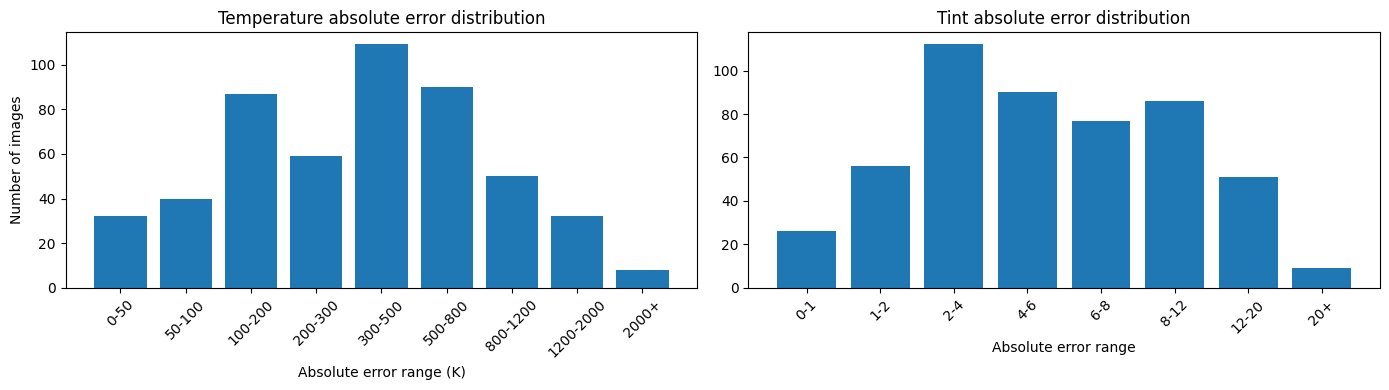


Temperature error summary:
  <= 100: 14.4% of samples
  <= 200: 31.7% of samples
  <= 300: 43.1% of samples
  <= 500: 64.6% of samples
  <= 800: 82.1% of samples

Tint error summary:
  <= 1: 16.1% of samples
  <= 2: 28.5% of samples
  <= 4: 46.1% of samples
  <= 6: 64.0% of samples
  <= 8: 76.4% of samples
  <= 12: 89.8% of samples


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = r"val_predictions_efficientnet_v2_s_model_new_woo.csv"

TEMP_BINS = [0, 50, 100, 200, 300, 500, 800, 1200, 2000, 5000]
TEMP_LABELS = [
    "0-50", "50-100", "100-200", "200-300", "300-500",
    "500-800", "800-1200", "1200-2000", "2000+"
]

TINT_BINS = [0, 1, 2, 4, 6, 8, 12, 20, 50]
TINT_LABELS = ["0-1", "1-2", "2-4", "4-6", "6-8", "8-12", "12-20", "20+"]

TEMP_THRESHOLDS = [100, 200, 300, 500, 800]
TINT_THRESHOLDS = [1, 2, 4, 6, 8, 12]


def load_predictions(path: str) -> pd.DataFrame:

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())

    required_cols = [
        "Temperature", "Tint",
        "pred_Temperature", "pred_Tint"
    ]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
    df["Tint"] = pd.to_numeric(df["Tint"], errors="coerce")
    df["pred_Temperature"] = pd.to_numeric(df["pred_Temperature"], errors="coerce")
    df["pred_Tint"] = pd.to_numeric(df["pred_Tint"], errors="coerce")

    #  actual - predicted
    df["diff_temp"] = df["Temperature"] - df["pred_Temperature"]
    df["diff_tint"] = df["Tint"] - df["pred_Tint"]

    df["abs_diff_temp"] = df["diff_temp"].abs()
    df["abs_diff_tint"] = df["diff_tint"].abs()

    return df


def bin_errors(df: pd.DataFrame):

    df["temp_error_bin"] = pd.cut(
        df["abs_diff_temp"],
        bins=TEMP_BINS,
        labels=TEMP_LABELS,
        include_lowest=True,
        right=False,
    )
    temp_counts = df["temp_error_bin"].value_counts().sort_index()

    df["tint_error_bin"] = pd.cut(
        df["abs_diff_tint"],
        bins=TINT_BINS,
        labels=TINT_LABELS,
        include_lowest=True,
        right=False,
    )
    tint_counts = df["tint_error_bin"].value_counts().sort_index()

    return temp_counts, tint_counts


def print_bucket_counts(temp_counts, tint_counts):

    print("\n==============================")
    print(" TEMPERATURE ERROR BUCKETS")
    print("==============================")
    for label, count in zip(temp_counts.index.astype(str), temp_counts.values):
        print(f"{label:<12} : {count} images")

    print("\n==============================")
    print(" TINT ERROR BUCKETS")
    print("==============================")
    for label, count in zip(tint_counts.index.astype(str), tint_counts.values):
        print(f"{label:<12} : {count} images")


def plot_error_distributions(temp_counts, tint_counts) -> None:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))


    axes[0].bar(temp_counts.index.astype(str), temp_counts.values)
    axes[0].set_title("Temperature absolute error distribution")
    axes[0].set_xlabel("Absolute error range (K)")
    axes[0].set_ylabel("Number of images")
    axes[0].tick_params(axis="x", rotation=45)

    # Tint error distribution
    axes[1].bar(tint_counts.index.astype(str), tint_counts.values)
    axes[1].set_title("Tint absolute error distribution")
    axes[1].set_xlabel("Absolute error range")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def summarize_error(df: pd.DataFrame, col: str, name: str, thresholds) -> None:

    print(f"\n{name} error summary:")
    for t in thresholds:
        frac = (df[col] <= t).mean() * 100
        print(f"  <= {t}: {frac:.1f}% of samples")


def main():
    df = load_predictions(CSV_PATH)

    temp_counts, tint_counts = bin_errors(df)

    print_bucket_counts(temp_counts, tint_counts)

    plot_error_distributions(temp_counts, tint_counts)

    summarize_error(df, "abs_diff_temp", "Temperature", TEMP_THRESHOLDS)
    summarize_error(df, "abs_diff_tint", "Tint", TINT_THRESHOLDS)


if __name__ == "__main__":
    main()


# VISUALTION ON FULL TRAIN DATA PREDICTION

Columns: ['id_global', 'Actual_currTemp', 'Actual_currTint', 'pred_Temperature', 'pred_Tint', 'Temperature', 'Tint']

 TEMPERATURE ERROR BUCKETS
0-50         : 329 images
50-100       : 325 images
100-200      : 580 images
200-300      : 430 images
300-500      : 495 images
500-800      : 253 images
800-1200     : 79 images
1200-2000    : 33 images
2000+        : 11 images

 TINT ERROR BUCKETS
0-1          : 207 images
1-2          : 377 images
2-4          : 721 images
4-6          : 520 images
6-8          : 309 images
8-12         : 291 images
12-20        : 99 images
20+          : 13 images


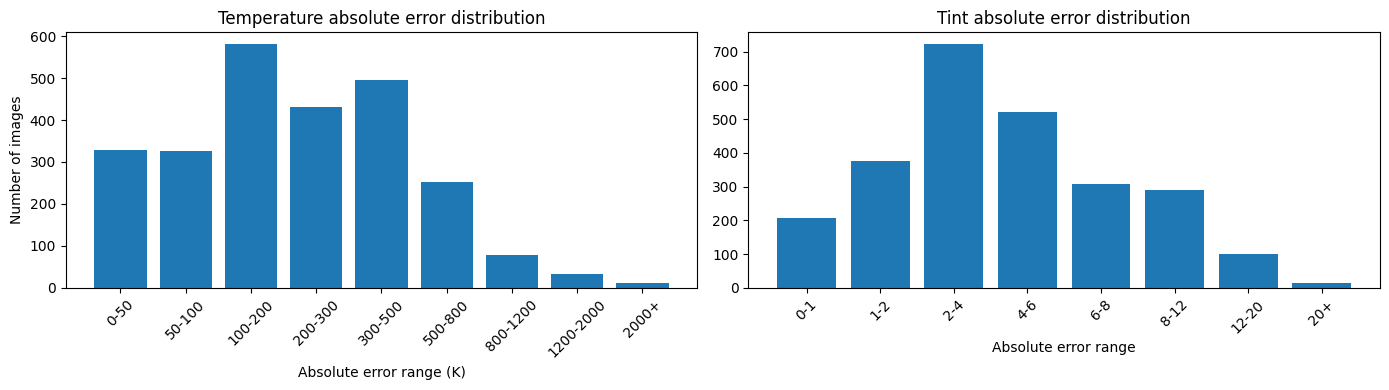


Temperature error summary:
  <= 100: 25.8% of samples
  <= 200: 49.1% of samples
  <= 300: 65.9% of samples
  <= 500: 85.2% of samples
  <= 800: 95.1% of samples

Tint error summary:
  <= 1: 23.0% of samples
  <= 2: 37.8% of samples
  <= 4: 61.5% of samples
  <= 6: 78.2% of samples
  <= 8: 88.3% of samples
  <= 12: 96.7% of samples


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = r"PRED_TRAINING_DATA__model_new_woo_.csv"

TEMP_BINS = [0, 50, 100, 200, 300, 500, 800, 1200, 2000, 5000]
TEMP_LABELS = [
    "0-50", "50-100", "100-200", "200-300", "300-500",
    "500-800", "800-1200", "1200-2000", "2000+"
]

TINT_BINS = [0, 1, 2, 4, 6, 8, 12, 20, 50]
TINT_LABELS = ["0-1", "1-2", "2-4", "4-6", "6-8", "8-12", "12-20", "20+"]

TEMP_THRESHOLDS = [100, 200, 300, 500, 800]
TINT_THRESHOLDS = [1, 2, 4, 6, 8, 12]


def load_predictions(path: str) -> pd.DataFrame:

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())

    required_cols = [
        "Temperature", "Tint",
        "pred_Temperature", "pred_Tint"
    ]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
    df["Tint"] = pd.to_numeric(df["Tint"], errors="coerce")
    df["pred_Temperature"] = pd.to_numeric(df["pred_Temperature"], errors="coerce")
    df["pred_Tint"] = pd.to_numeric(df["pred_Tint"], errors="coerce")

    #  actual - predicted
    df["diff_temp"] = df["Temperature"] - df["pred_Temperature"]
    df["diff_tint"] = df["Tint"] - df["pred_Tint"]

    df["abs_diff_temp"] = df["diff_temp"].abs()
    df["abs_diff_tint"] = df["diff_tint"].abs()

    return df


def bin_errors(df: pd.DataFrame):

    df["temp_error_bin"] = pd.cut(
        df["abs_diff_temp"],
        bins=TEMP_BINS,
        labels=TEMP_LABELS,
        include_lowest=True,
        right=False,
    )
    temp_counts = df["temp_error_bin"].value_counts().sort_index()

    df["tint_error_bin"] = pd.cut(
        df["abs_diff_tint"],
        bins=TINT_BINS,
        labels=TINT_LABELS,
        include_lowest=True,
        right=False,
    )
    tint_counts = df["tint_error_bin"].value_counts().sort_index()

    return temp_counts, tint_counts


def print_bucket_counts(temp_counts, tint_counts):

    print("\n==============================")
    print(" TEMPERATURE ERROR BUCKETS")
    print("==============================")
    for label, count in zip(temp_counts.index.astype(str), temp_counts.values):
        print(f"{label:<12} : {count} images")

    print("\n==============================")
    print(" TINT ERROR BUCKETS")
    print("==============================")
    for label, count in zip(tint_counts.index.astype(str), tint_counts.values):
        print(f"{label:<12} : {count} images")


def plot_error_distributions(temp_counts, tint_counts) -> None:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))


    axes[0].bar(temp_counts.index.astype(str), temp_counts.values)
    axes[0].set_title("Temperature absolute error distribution")
    axes[0].set_xlabel("Absolute error range (K)")
    axes[0].set_ylabel("Number of images")
    axes[0].tick_params(axis="x", rotation=45)

    # Tint error distribution
    axes[1].bar(tint_counts.index.astype(str), tint_counts.values)
    axes[1].set_title("Tint absolute error distribution")
    axes[1].set_xlabel("Absolute error range")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def summarize_error(df: pd.DataFrame, col: str, name: str, thresholds) -> None:

    print(f"\n{name} error summary:")
    for t in thresholds:
        frac = (df[col] <= t).mean() * 100
        print(f"  <= {t}: {frac:.1f}% of samples")


def main():
    df = load_predictions(CSV_PATH)

    temp_counts, tint_counts = bin_errors(df)

    print_bucket_counts(temp_counts, tint_counts)

    plot_error_distributions(temp_counts, tint_counts)

    summarize_error(df, "abs_diff_temp", "Temperature", TEMP_THRESHOLDS)
    summarize_error(df, "abs_diff_tint", "Tint", TINT_THRESHOLDS)


if __name__ == "__main__":
    main()


# Fine-Tuning Script

This code executes the core training loop for our final model. It is designed specifically for the fine-tuning stage, leveraging the knowledge gained from initial training runs while upgrading the model's visual input to a higher resolution.

## 1. Project Configuration and Fine-Tuning Setup

 The $\mathbf{CONFIG}$ dictionary defines the aggressive parameters for the final optimization push:

 - Progressive Resizing: The $\mathbf{IMG\_SIZE}$ is set to $\mathbf{384}$, increasing the input data resolution from the initial $256 \times 256$ stage. This allows the model to learn finer details for better precision.

 - Transfer Learning Target: The $\mathbf{PREVIOUS\_BEST\_MODEL\_PATH}$ is defined. This is the source of the weights we load before training begins, allowing us to build on past performance rather than starting over.

 - Conservative Learning Rate ($\mathbf{LR: 1e-5}$): A very low learning rate is used. This is a non-negotiable step for fine-tuning, as it ensures the model makes only small, careful adjustments to its pre-trained weights, preventing catastrophic loss of information.

 - Metric: The $\mathbf{Avg MAE}$ is the sole metric monitored to drive checkpoint saving.

 ## 2. Data Handling and Augmentation (WhiteBalanceDataset)

 The ```WhiteBalanceDataset``` class is retained from earlier stages, handling the complex tasks of reading mixed file formats ($\text{.tif}$, $\text{.jpg}$) and normalizing the targets ($\text{Temperature}$ and $\text{Tint}$) by scaling them down.

 ### Augmentation Strategy

 The aug_transforms pipeline is applied to the training set. It includes:

 - Geometric Invariance: $\text{RandomResizedCrop}$, $\text{RandomHorizontalFlip}$, and $\text{RandomRotation}$ teach the model to ignore slight changes in perspective.

 - Color Invariance (Crucial for WB): $\text{ColorJitter}$ randomly alters brightness, contrast, saturation, and hue. This is the most critical augmentation, as it forces the model to learn the true lighting conditions of the scene despite spurious color shifts introduced by the augmentation itself.

 ### 3. Training and Validation Loop

 The core logic ensures stable and efficient convergence.

 - Model Loading: Before the loop starts, the main function executes the critical step of loading the weights from $\mathbf{PREVIOUS\_BEST\_MODEL\_PATH}$ into the EfficientNetV2Regressor instance.

 - Loss Function ($\text{nn.MSELoss}$): Mean Squared Error remains the chosen loss function because its squaring action aggressively penalizes large errors, which effectively targets and reduces the high $\text{Temperature}$ outliers.

 - Optimization Techniques:

    * $\mathbf{\text{AdamW}}$ is used as the optimizer with a low $\mathbf{LR}$ and $\mathbf{WEIGHT\_DECAY}$ (L2 regularization) to prevent weight explosion.

    * $\mathbf{\text{GradScaler}}$ (Automatic Mixed Precision/AMP) is enabled for $\text{cuda}$ devices. This significantly speeds up training and reduces memory usage by performing computations in half-precision ($\text{FP16}$) where possible.

 - Dynamic Learning Rate: The $\mathbf{\text{ReduceLROnPlateau}}$ scheduler monitors the validation $\text{Avg MAE}$. If performance plateaus, the learning rate is automatically decreased by a factor of $0.2$, allowing the model to make finer, more precise updates.

 - Checkpointing: The model weights are saved to $\mathbf{BEST\_MODEL\_PATH}$ only when the validation $\text{Avg MAE}$ achieves a new historical minimum, ensuring we retain the best possible model instance.

 ## 4. Final Output GenerationThe save_predictions_csv function executes once training is complete:

 - It loads the model that achieved the best performance (the checkpoint saved during training).

 - It uses this best model to predict values on the validation set.

 - It performs the necessary post-processing: the scaled predictions are converted back to real units ($\text{Kelvin}$ and $\text{Tint}$), clipped to the valid range, and rounded to integers to meet the final submission format.

 - It saves the final predictions and prints the final, clean $\text{Avg MAE}$ achieved by the integer-rounded predictions.

# FINETUNING

In [18]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler

import tifffile
from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from tqdm.auto import tqdm
from torch.cuda.amp import GradScaler

CONFIG = {
    'TRAIN_CSV': r'/content/drive/MyDrive/dataset/Train/sliders.csv',
    'TRAIN_IMG_DIR': r'/content/drive/MyDrive/dataset/Train/images',

    'PREVIOUS_BEST_MODEL_PATH': 'model_new_woo_.pth',

    'MODEL_NAME': 'efficientnet_v2_s',

    'BATCH_SIZE': 6,
    'LR': 1e-5,
    'EPOCHS': 15,
    'IMG_SIZE': 384,

    'NUM_WORKERS': 2,

    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'BEST_MODEL_PATH': 'best_model_new_woo_finetune.pth',
    'PRED_CSV_PATH': 'val_predictions_best_model_new_woo_finetune.csv',

    'WEIGHT_DECAY': 5e-4,
    'DROPOUT_RATE': 0.4,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0
TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class WhiteBalanceDataset(Dataset):
    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:
        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        raise FileNotFoundError(
            f"No image file found for id '{img_id}' in {self.img_dir} with extensions: {exts}"
        )

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()
        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])
        img_path = self._resolve_image_path(img_id)
        img = self._read_image(img_path)

        # transforms pipeline handles the resizing to 384x384
        pixel_values = self.processor(img)

        temp = float(row["Temperature"])
        tint = float(row["Tint"])
        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):
    def __init__(self, model_name, num_targets, dropout_rate):
        super().__init__()

        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets)
        )

    def forward(self, x):
        return self.effnet(x)


def train_one_epoch(model, loader, criterion, optimizer, device, epoch, cfg, scaler=None):
    model.train()
    running_loss = 0.0

    all_gt_temp = []
    all_gt_tint = []
    all_pred_temp = []
    all_pred_tint = []

    for pixel_values, targets_scaled, _ in tqdm(
            loader, desc=f"Fine-Tune Epoch {epoch}/{cfg['EPOCHS']}", leave=True
    ):
        pixel_values = pixel_values.to(device)
        targets_scaled = targets_scaled.to(device)

        optimizer.zero_grad()

        if scaler is not None and device == 'cuda':
            with torch.amp.autocast('cuda'):
                preds_scaled = model(pixel_values)
                loss = criterion(preds_scaled, targets_scaled)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds_scaled = model(pixel_values)
            loss = criterion(preds_scaled, targets_scaled)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * targets_scaled.size(0)

        preds_scaled_np = preds_scaled.detach().cpu().numpy()
        targets_scaled_np = targets_scaled.detach().cpu().numpy()

        gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
        gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
        pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
        pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

        all_gt_temp.append(gt_temp)
        all_gt_tint.append(gt_tint)
        all_pred_temp.append(pred_temp)
        all_pred_tint.append(pred_tint)

    all_gt_temp = np.concatenate(all_gt_temp)
    all_gt_tint = np.concatenate(all_gt_tint)
    all_pred_temp = np.concatenate(all_pred_temp)
    all_pred_tint = np.concatenate(all_pred_tint)

    temp_mae = mean_absolute_error(all_gt_temp, all_pred_temp)
    tint_mae = mean_absolute_error(all_gt_tint, all_pred_tint)
    avg_mae = (temp_mae + tint_mae) / 2.0

    epoch_loss = running_loss / len(loader)

    return epoch_loss, avg_mae, temp_mae, tint_mae


def validate_one_epoch(model, loader, criterion, device, epoch, cfg):
    model.eval()
    running_loss = 0.0

    all_gt_temp = []
    all_gt_tint = []
    all_pred_temp = []
    all_pred_tint = []

    with torch.no_grad():
        for pixel_values, targets_scaled, _ in tqdm(
                loader, desc=f"Valid Epoch {epoch}/{cfg['EPOCHS']}", leave=True
        ):
            pixel_values = pixel_values.to(device)
            targets_scaled = targets_scaled.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
                    loss = criterion(preds_scaled, targets_scaled)
            else:
                preds_scaled = model(pixel_values)
                loss = criterion(preds_scaled, targets_scaled)

            running_loss += loss.item() * targets_scaled.size(0)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            all_gt_temp.append(gt_temp)
            all_gt_tint.append(gt_tint)
            all_pred_temp.append(pred_temp)
            all_pred_tint.append(pred_tint)

    epoch_loss = running_loss / len(loader)

    all_gt_temp = np.concatenate(all_gt_temp)
    all_gt_tint = np.concatenate(all_gt_tint)
    all_pred_temp = np.concatenate(all_pred_temp)
    all_pred_tint = np.concatenate(all_pred_tint)

    temp_mae = mean_absolute_error(all_gt_temp, all_pred_temp)
    tint_mae = mean_absolute_error(all_gt_tint, all_pred_tint)
    avg_mae = (temp_mae + tint_mae) / 2.0

    return epoch_loss, avg_mae, temp_mae, tint_mae


def save_predictions_csv(model, dataset, device, cfg):
    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda')
    )

    model.eval()
    all_ids = []
    all_temp = []
    all_tint = []
    all_pred_temp_raw = []
    all_pred_tint_raw = []

    with torch.no_grad():
        for pixel_values, targets_scaled, img_ids in tqdm(
                loader, desc="Generating CSV", leave=True
        ):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            gt_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            gt_tint = targets_scaled_np[:, 1] * TINT_SCALE
            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_temp.append(gt_temp[i])
                all_tint.append(gt_tint[i])
                all_pred_temp_raw.append(pred_temp[i])
                all_pred_tint_raw.append(pred_tint[i])

    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Temperature': all_temp,
        'Tint': all_tint,
        'pred_Temperature': all_pred_temp_raw,
        'pred_Tint': all_pred_tint_raw,
    })

    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )
    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )

    df_out["Temperature"] = df_out["Temperature"].round().astype(int)
    df_out["Tint"] = df_out["Tint"].round().astype(int)

    # Save
    df_out.to_csv(cfg['PRED_CSV_PATH'], index=False)
    print(f"\nSaved predictions CSV to: {cfg['PRED_CSV_PATH']}")
    print(df_out.head())

    # Also print a clean MAE summary using the rounded predictions
    mae_temp = np.mean(np.abs(df_out["Temperature"] - df_out["pred_Temperature"]))
    mae_tint = np.mean(np.abs(df_out["Tint"] - df_out["pred_Tint"]))
    mae_avg = (mae_temp + mae_tint) / 2.0

    print("\n--- Prediction Summary (rounded ints) ---")
    print(f"Temp MAE: {mae_temp:.2f}")
    print(f"Tint MAE: {mae_tint:.2f}")
    print(f"Avg MAE:  {mae_avg:.2f}")


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")
    print(f"Starting {cfg['IMG_SIZE']}x{cfg['IMG_SIZE']} Fine-Tuning with LR: {cfg['LR']:.2e}")

    # 6.1 Load CSV and split
    df = pd.read_csv(cfg['TRAIN_CSV'])
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    # (using new IMG_SIZE for upscaling)
    IMG_SIZE = cfg['IMG_SIZE']
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]

    base_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])

    aug_transforms = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.05
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
    ])

    train_dataset = WhiteBalanceDataset(train_df, cfg['TRAIN_IMG_DIR'], processor=aug_transforms, id_col='id_global')
    val_dataset = WhiteBalanceDataset(val_df, cfg['TRAIN_IMG_DIR'], processor=base_transforms, id_col='id_global')

    train_loader = DataLoader(
        train_dataset, batch_size=cfg['BATCH_SIZE'], shuffle=True,
        num_workers=cfg['NUM_WORKERS'], pin_memory=(device == 'cuda')
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg['BATCH_SIZE'], shuffle=False,
        num_workers=cfg['NUM_WORKERS'], pin_memory=(device == 'cuda')
    )

    model = EfficientNetV2Regressor(
        cfg['MODEL_NAME'], num_targets=2, dropout_rate=cfg['DROPOUT_RATE']
    ).to(device)

    # --- CRITICAL FINE-TUNING STEP: LOAD PREVIOUS WEIGHTS ---
    if os.path.exists(cfg['PREVIOUS_BEST_MODEL_PATH']):
        try:
            model.load_state_dict(torch.load(cfg['PREVIOUS_BEST_MODEL_PATH'], map_location=device))
            print(f">> Successfully loaded best weights from: {cfg['PREVIOUS_BEST_MODEL_PATH']} for fine-tuning.")
        except RuntimeError as e:
            print(f"XX Error loading state dict. Starting from ImageNet pre-trained weights. Error: {e}")
    else:
        print(
            f" ---  Warning: Previous model checkpoint not found at {cfg['PREVIOUS_BEST_MODEL_PATH']}. Starting from ImageNet pre-trained weights.")
    # --------------------------------------------------------

    criterion = nn.MSELoss(reduction='mean')

    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg['LR'],  #  low LR for fine-tuning
        weight_decay=cfg['WEIGHT_DECAY']
    )

    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        # verbose=True
    )

    scaler = GradScaler() if device == 'cuda' else None

    print(f"Model has {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

    best_val_mae = float('inf')

    for epoch in range(1, cfg['EPOCHS'] + 1):
        train_loss, train_mae, train_temp_mae, train_tint_mae = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch, cfg, scaler=scaler
        )

        val_loss, val_mae, val_temp_mae, val_tint_mae = validate_one_epoch(
            model, val_loader, criterion, device, epoch, cfg
        )

        scheduler.step(val_mae)

        print(
            f"Epoch {epoch}/{cfg['EPOCHS']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Valid Avg_MAE: {val_mae:.2f} "
            f"(Temp: {val_temp_mae:.2f}, Tint: {val_tint_mae:.2f}) | "
            f"Current LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), cfg['BEST_MODEL_PATH'])
            print(f"[Checkpoint] New best Avg_MAE saved: {best_val_mae:.2f}")

    print("\nTraining finished.")
    print(f"Best validation Avg_MAE achieved: {best_val_mae:.2f}")

    if os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\nLoading best model from: {cfg['BEST_MODEL_PATH']}")
        model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    else:
        print("\n[Warning] Best model file not found, using last-epoch weights.")

    save_predictions_csv(model, val_dataset, device, cfg)


if __name__ == "__main__":
    main()

Using device: cuda
Starting 384x384 Fine-Tuning with LR: 1.00e-05
>> Successfully loaded best weights from: model_new_woo_.pth for fine-tuning.
Model has 20.18M parameters


/tmp/ipython-input-828965900.py:395: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if device == 'cuda' else None


Fine-Tune Epoch 1/15:   0%|          | 0/339 [00:00<?, ?it/s]

Valid Epoch 1/15:   0%|          | 0/85 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 0.0145 | Valid Avg_MAE: 315.18 (Temp: 624.49, Tint: 5.88) | Current LR: 1.00e-05
[Checkpoint] New best Avg_MAE saved: 315.18


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4cb2ddd6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4cb2ddd6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Valid Epoch 15/15:   0%|          | 0/85 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.0094 | Valid Avg_MAE: 270.56 (Temp: 535.37, Tint: 5.76) | Current LR: 1.00e-05
[Checkpoint] New best Avg_MAE saved: 270.56

Training finished.
Best validation Avg_MAE achieved: 270.56

Loading best model from: best_model_new_woo_finetune.pth


Generating CSV:   0%|          | 0/85 [00:00<?, ?it/s]


Saved predictions CSV to: val_predictions_best_model_new_woo_finetune.csv
                              id_global  Temperature  Tint  pred_Temperature  \
0  5CDA7800-F4FD-4779-9968-9616A1EDF5CD         4000    -1              4082   
1  704AEDF9-8A99-418B-BFDB-95130DC82EC6         4250    19              4508   
2  ECB59F59-6364-4F13-8408-AD199346DB83         4500    14              4656   
3  430F1CA2-7217-40A4-9D89-911582B4B1F5         2000    -4              2836   
4  4DE52227-9FC8-44AC-A35E-61765871A091         5750    15              5604   

   pred_Tint  
0          0  
1         22  
2         20  
3         -1  
4         14  

--- Prediction Summary (rounded ints) ---
Temp MAE: 529.31
Tint MAE: 5.78
Avg MAE:  267.54


# TESTING FINETUNE VALID DATA

In [19]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tifffile
from PIL import Image
from torchvision import transforms, models
from tqdm.auto import tqdm

CONFIG = {

    'NEW_DATA_CSV': r'/content/drive/MyDrive/dataset/Validation/sliders_input.csv',
    'NEW_IMG_DIR': r'/content/drive/MyDrive/dataset/Validation/images',

    'MODEL_NAME': 'efficientnet_v2_s',
    'BEST_MODEL_PATH': 'best_model_new_woo_finetune.pth',
    'OUTPUT_PRED_CSV_PATH': 'FINETUNE_PRED_TEST_VALL_best_model_new_woo_finetune.csv',


    'BATCH_SIZE': 8,
    'NUM_WORKERS': 2,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',

    'IMG_SIZE': 256,
    'DROPOUT_RATE': 0.4,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0

TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class DatasetPrepWorker(Dataset):

    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:

        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        return None

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()

        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):

                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)

                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])

        img_path = self._resolve_image_path(img_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for ID: {img_id}")

        img = self._read_image(img_path)
        pixel_values = self.processor(img)

        try:
            # Existing logic for ground truth: uses 'currTemp' and 'currTint'
            temp = float(row["currTemp"])
            tint = float(row["currTint"])
        except KeyError:
            temp, tint = np.nan, np.nan

        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):

    def __init__(self, model_name: str, num_targets: int, dropout_rate: float):
        super().__init__()

        # Base model
        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets),
        )

    def forward(self, x):
        return self.effnet(x)


def make_predictions(model: nn.Module,
                     dataset: Dataset,
                     device: str,
                     cfg: dict,
                     df_full_input: pd.DataFrame = None) -> None:

    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda'),
    )

    model.eval()

    all_ids = []
    all_actual_temp = []
    all_actual_tint = []
    all_pred_temp = []
    all_pred_tint = []

    print(f"\nStarting prediction on {len(dataset)} samples...")

    with torch.inference_mode():
        for pixel_values, targets_scaled, img_ids in tqdm(loader, desc="Predicting", leave=True):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            actual_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            actual_tint = targets_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_actual_temp.append(actual_temp[i])
                all_actual_tint.append(actual_tint[i])
                all_pred_temp.append(pred_temp[i])
                all_pred_tint.append(pred_tint[i])

    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Actual_currTemp': all_actual_temp,
        'Actual_currTint': all_actual_tint,
        'pred_Temperature': all_pred_temp,
        'pred_Tint': all_pred_tint,
    })

    if df_full_input is not None:
        passthrough_cols = []
        if 'Temperature' in df_full_input.columns:
            passthrough_cols.append('Temperature')
        if 'Tint' in df_full_input.columns:
            passthrough_cols.append('Tint')

        if passthrough_cols:

            df_out = df_out.merge(df_full_input[['id_global'] + passthrough_cols], on='id_global', how='left')
    # --------------------------------------------------------------------------------------

    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )

    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )

    df_out["Actual_currTemp"] = df_out["Actual_currTemp"].round()
    df_out["Actual_currTint"] = df_out["Actual_currTint"].round()

    df_out.to_csv(cfg['OUTPUT_PRED_CSV_PATH'], index=False)
    print(f"\n>>  Predictions saved successfully to: {cfg['OUTPUT_PRED_CSV_PATH']}")

    print("\n--- Sample Predictions ---")
    print(df_out.head())

    print("\n--- Prediction Summary ---")
    if not df_out['Actual_currTemp'].isnull().all():
        mae_temp = np.nanmean(np.abs(df_out['Actual_currTemp'] - df_out['pred_Temperature']))
        mae_tint = np.nanmean(np.abs(df_out['Actual_currTint'] - df_out['pred_Tint']))
        mae_avg = (mae_temp + mae_tint) / 2.0

        print(f"Calculated Avg MAE: {mae_avg:.2f}")
        print(f"Calculated Temp MAE: {mae_temp:.2f}")
        print(f"Calculated Tint MAE: {mae_tint:.2f}")
    else:
        print("Ground-truth currTemp/currTint not available; MAE not computed.")


def build_transforms(img_size: int):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std),
    ])


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")

    if not os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\n XX ERROR: Best model file not found at {cfg['BEST_MODEL_PATH']}")
        print("Please ensure you have completed training and the file path is correct.")
        return

    df_new_data = pd.read_csv(cfg['NEW_DATA_CSV'])
    print(f"Loaded new data CSV: {cfg['NEW_DATA_CSV']}")
    print(f"Rows: {len(df_new_data)}")

    transforms_infer = build_transforms(cfg['IMG_SIZE'])

    pred_dataset = DatasetPrepWorker(
        df=df_new_data,
        img_dir=cfg['NEW_IMG_DIR'],
        processor=transforms_infer,
        id_col='id_global',
    )

    model = EfficientNetV2Regressor(
        model_name=cfg['MODEL_NAME'],
        num_targets=2,
        dropout_rate=cfg['DROPOUT_RATE'],
    ).to(device)

    model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    print(f"\n>> Successfully loaded weights from: {cfg['BEST_MODEL_PATH']}")

    make_predictions(model, pred_dataset, device, cfg, df_full_input=df_new_data)


if __name__ == "__main__":
    main()

Using device: cuda
Loaded new data CSV: /content/drive/MyDrive/dataset/Validation/sliders_input.csv
Rows: 493

>> Successfully loaded weights from: best_model_new_woo_finetune.pth

Starting prediction on 493 samples...


Predicting:   0%|          | 0/62 [00:00<?, ?it/s]


>>  Predictions saved successfully to: FINETUNE_PRED_TEST_VALL_best_model_new_woo_finetune.csv

--- Sample Predictions ---
                              id_global  Actual_currTemp  Actual_currTint  \
0  EB5BEE31-8D4F-450A-8BDD-27C762C75AA6           6613.0             14.0   
1  DE666E1F-0433-4958-AEC0-9A0CC0F81036           6613.0             14.0   
2  F6A6EA9C-A5C2-4BBA-9812-5CE52B818CB6           6613.0             14.0   
3  BCC39DEF-598C-491A-A3CA-14A249717F36           6782.0             14.0   
4  390ED94E-0066-4822-99B9-8F1568BDFBF5           6782.0             14.0   

   pred_Temperature  pred_Tint  
0              4848         13  
1              4576         12  
2              5096         10  
3              3992          6  
4              3898         10  

--- Prediction Summary ---
Calculated Avg MAE: 1402.46
Calculated Temp MAE: 2795.59
Calculated Tint MAE: 9.32


# TESTING FINETUNE on Full train data

In [20]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tifffile
from PIL import Image
from torchvision import transforms, models
from tqdm.auto import tqdm

CONFIG = {

    'NEW_DATA_CSV': r'/content/drive/MyDrive/dataset/Train/sliders.csv',
    'NEW_IMG_DIR': r'/content/drive/MyDrive/dataset/Train/images',

    'MODEL_NAME': 'efficientnet_v2_s',
    'BEST_MODEL_PATH': 'best_model_new_woo_finetune.pth',
    'OUTPUT_PRED_CSV_PATH': 'FINETUNING_PRED_TRAINING_DATA_best_model_new_woo_finetune.pth.csv',


    'BATCH_SIZE': 8,
    'NUM_WORKERS': 2,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',

    'IMG_SIZE': 256,
    'DROPOUT_RATE': 0.4,
}

TEMP_SCALE = 10000.0
TINT_SCALE = 200.0

TEMP_MIN, TEMP_MAX = 1500.0, 10000.0
TINT_MIN, TINT_MAX = -50.0, 50.0


class DatasetPrepWorker(Dataset):

    def __init__(self, df, img_dir, processor, id_col='id_global'):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, img_id: str) -> str:

        exts = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
        for ext in exts:
            cand = os.path.join(self.img_dir, img_id + ext)
            if os.path.exists(cand):
                return cand
        return None

    def _read_image(self, img_path: str) -> Image.Image:
        ext = os.path.splitext(img_path)[1].lower()

        if ext in ['.tif', '.tiff']:
            img = tifffile.imread(img_path)
            if isinstance(img, np.ndarray):

                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)

                elif img.ndim == 3 and img.shape[0] in [1, 3]:
                    img = np.transpose(img, (1, 2, 0))
                img = Image.fromarray(img.astype(np.uint8))
        else:
            img = Image.open(img_path).convert('RGB')

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row[self.id_col])

        img_path = self._resolve_image_path(img_id)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for ID: {img_id}")

        img = self._read_image(img_path)
        pixel_values = self.processor(img)

        try:
            # Existing logic for ground truth: uses 'currTemp' and 'currTint'
            temp = float(row["currTemp"])
            tint = float(row["currTint"])
        except KeyError:
            temp, tint = np.nan, np.nan

        temp_scaled = temp / TEMP_SCALE
        tint_scaled = tint / TINT_SCALE
        targets = torch.tensor([temp_scaled, tint_scaled], dtype=torch.float32)

        return pixel_values, targets, img_id


class EfficientNetV2Regressor(nn.Module):

    def __init__(self, model_name: str, num_targets: int, dropout_rate: float):
        super().__init__()

        # Base model
        self.effnet = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.DEFAULT
        )

        in_features = self.effnet.classifier[-1].in_features

        self.effnet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_targets),
        )

    def forward(self, x):
        return self.effnet(x)


def make_predictions(model: nn.Module,
                     dataset: Dataset,
                     device: str,
                     cfg: dict,
                     df_full_input: pd.DataFrame = None) -> None:

    loader = DataLoader(
        dataset,
        batch_size=cfg['BATCH_SIZE'],
        shuffle=False,
        num_workers=cfg['NUM_WORKERS'],
        pin_memory=(device == 'cuda'),
    )

    model.eval()

    all_ids = []
    all_actual_temp = []
    all_actual_tint = []
    all_pred_temp = []
    all_pred_tint = []

    print(f"\nStarting prediction on {len(dataset)} samples...")

    with torch.inference_mode():
        for pixel_values, targets_scaled, img_ids in tqdm(loader, desc="Predicting", leave=True):
            pixel_values = pixel_values.to(device)

            if device == 'cuda':
                with torch.amp.autocast('cuda'):
                    preds_scaled = model(pixel_values)
            else:
                preds_scaled = model(pixel_values)

            preds_scaled_np = preds_scaled.detach().cpu().numpy()
            targets_scaled_np = targets_scaled.detach().cpu().numpy()

            pred_temp = preds_scaled_np[:, 0] * TEMP_SCALE
            pred_tint = preds_scaled_np[:, 1] * TINT_SCALE

            actual_temp = targets_scaled_np[:, 0] * TEMP_SCALE
            actual_tint = targets_scaled_np[:, 1] * TINT_SCALE

            for i in range(len(img_ids)):
                all_ids.append(img_ids[i])
                all_actual_temp.append(actual_temp[i])
                all_actual_tint.append(actual_tint[i])
                all_pred_temp.append(pred_temp[i])
                all_pred_tint.append(pred_tint[i])

    df_out = pd.DataFrame({
        'id_global': all_ids,
        'Actual_currTemp': all_actual_temp,
        'Actual_currTint': all_actual_tint,
        'pred_Temperature': all_pred_temp,
        'pred_Tint': all_pred_tint,
    })

    if df_full_input is not None:
        passthrough_cols = []
        if 'Temperature' in df_full_input.columns:
            passthrough_cols.append('Temperature')
        if 'Tint' in df_full_input.columns:
            passthrough_cols.append('Tint')

        if passthrough_cols:

            df_out = df_out.merge(df_full_input[['id_global'] + passthrough_cols], on='id_global', how='left')
    # --------------------------------------------------------------------------------------

    df_out["pred_Temperature"] = (
        df_out["pred_Temperature"]
        .clip(lower=TEMP_MIN, upper=TEMP_MAX)
        .round()
        .astype(int)
    )

    df_out["pred_Tint"] = (
        df_out["pred_Tint"]
        .clip(lower=TINT_MIN, upper=TINT_MAX)
        .round()
        .astype(int)
    )

    df_out["Actual_currTemp"] = df_out["Actual_currTemp"].round()
    df_out["Actual_currTint"] = df_out["Actual_currTint"].round()

    df_out.to_csv(cfg['OUTPUT_PRED_CSV_PATH'], index=False)
    print(f"\n>>  Predictions saved successfully to: {cfg['OUTPUT_PRED_CSV_PATH']}")

    print("\n--- Sample Predictions ---")
    print(df_out.head())

    print("\n--- Prediction Summary ---")
    if not df_out['Actual_currTemp'].isnull().all():
        mae_temp = np.nanmean(np.abs(df_out['Actual_currTemp'] - df_out['pred_Temperature']))
        mae_tint = np.nanmean(np.abs(df_out['Actual_currTint'] - df_out['pred_Tint']))
        mae_avg = (mae_temp + mae_tint) / 2.0

        print(f"Calculated Avg MAE: {mae_avg:.2f}")
        print(f"Calculated Temp MAE: {mae_temp:.2f}")
        print(f"Calculated Tint MAE: {mae_tint:.2f}")
    else:
        print("Ground-truth currTemp/currTint not available; MAE not computed.")


def build_transforms(img_size: int):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std),
    ])


def main():
    cfg = CONFIG
    device = cfg['DEVICE']
    print(f"Using device: {device}")

    if not os.path.exists(cfg['BEST_MODEL_PATH']):
        print(f"\n XX ERROR: Best model file not found at {cfg['BEST_MODEL_PATH']}")
        print("Please ensure you have completed training and the file path is correct.")
        return

    df_new_data = pd.read_csv(cfg['NEW_DATA_CSV'])
    print(f"Loaded new data CSV: {cfg['NEW_DATA_CSV']}")
    print(f"Rows: {len(df_new_data)}")

    transforms_infer = build_transforms(cfg['IMG_SIZE'])

    pred_dataset = DatasetPrepWorker(
        df=df_new_data,
        img_dir=cfg['NEW_IMG_DIR'],
        processor=transforms_infer,
        id_col='id_global',
    )

    model = EfficientNetV2Regressor(
        model_name=cfg['MODEL_NAME'],
        num_targets=2,
        dropout_rate=cfg['DROPOUT_RATE'],
    ).to(device)

    model.load_state_dict(torch.load(cfg['BEST_MODEL_PATH'], map_location=device))
    print(f"\n>> Successfully loaded weights from: {cfg['BEST_MODEL_PATH']}")

    make_predictions(model, pred_dataset, device, cfg, df_full_input=df_new_data)


if __name__ == "__main__":
    main()

Using device: cuda
Loaded new data CSV: /content/drive/MyDrive/dataset/Train/sliders.csv
Rows: 2538

>> Successfully loaded weights from: best_model_new_woo_finetune.pth

Starting prediction on 2538 samples...


Predicting:   0%|          | 0/318 [00:00<?, ?it/s]


>>  Predictions saved successfully to: FINETUNING_PRED_TRAINING_DATA_best_model_new_woo_finetune.pth.csv

--- Sample Predictions ---
                              id_global  Actual_currTemp  Actual_currTint  \
0  C68C8010-495C-4427-9F4D-664C2D71EFAD           6317.0              4.0   
1  8EFC0EC0-0936-41CC-81BD-513B35D2CB23           5767.0             13.0   
2  4A28220F-024E-4637-80ED-B4533578AFEB           5496.0              6.0   
3  05A76E40-9B2C-40FD-95D4-EF976598640C           3730.0             12.0   
4  B63A179E-232C-4133-BB24-8784B60DECEE           3661.0             -6.0   

   pred_Temperature  pred_Tint  Temperature  Tint  
0              3444         -8         4150     2  
1              3946          5         4700     4  
2              5280         13         5000    12  
3              3438          9         3150     9  
4              3382         10         3633     4  

--- Prediction Summary ---
Calculated Avg MAE: 454.59
Calculated Temp MAE: 902.12
Calculat

# VISUAL FINETUNE TRAIN DATA

Columns: ['id_global', 'Actual_currTemp', 'Actual_currTint', 'pred_Temperature', 'pred_Tint', 'Temperature', 'Tint']

 TEMPERATURE ERROR BUCKETS
0-50         : 176 images
50-100       : 231 images
100-200      : 399 images
200-300      : 360 images
300-500      : 603 images
500-800      : 517 images
800-1200     : 176 images
1200-2000    : 57 images
2000+        : 16 images

 TINT ERROR BUCKETS
0-1          : 216 images
1-2          : 379 images
2-4          : 651 images
4-6          : 504 images
6-8          : 323 images
8-12         : 326 images
12-20        : 124 images
20+          : 14 images


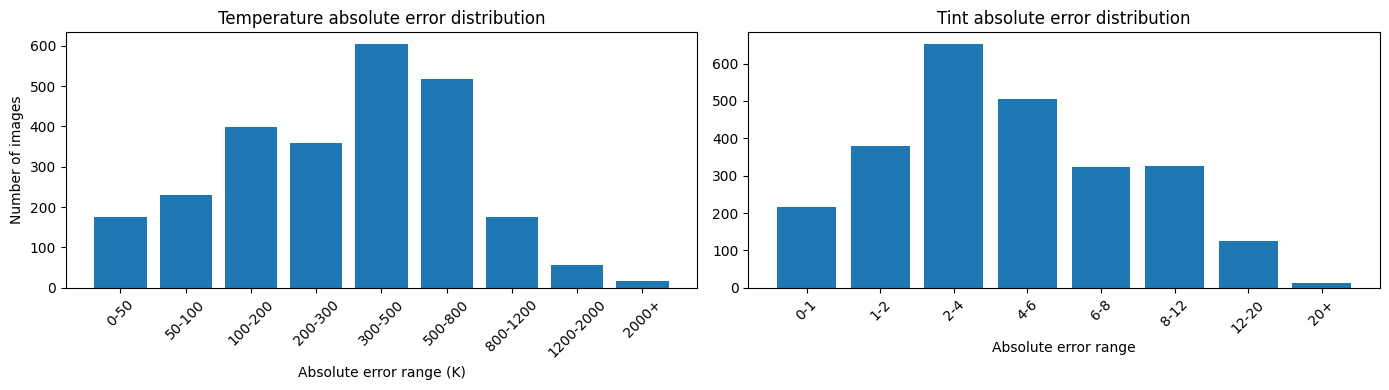


Temperature error summary:
  <= 100: 16.4% of samples
  <= 200: 32.0% of samples
  <= 300: 46.2% of samples
  <= 500: 69.9% of samples
  <= 800: 90.3% of samples

Tint error summary:
  <= 1: 23.4% of samples
  <= 2: 36.1% of samples
  <= 4: 59.7% of samples
  <= 6: 75.7% of samples
  <= 8: 86.3% of samples
  <= 12: 96.2% of samples


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = r"FINETUNING_PRED_TRAINING_DATA_best_model_new_woo_finetune.pth.csv"

TEMP_BINS = [0, 50, 100, 200, 300, 500, 800, 1200, 2000, 5000]
TEMP_LABELS = [
    "0-50", "50-100", "100-200", "200-300", "300-500",
    "500-800", "800-1200", "1200-2000", "2000+"
]

TINT_BINS = [0, 1, 2, 4, 6, 8, 12, 20, 50]
TINT_LABELS = ["0-1", "1-2", "2-4", "4-6", "6-8", "8-12", "12-20", "20+"]

TEMP_THRESHOLDS = [100, 200, 300, 500, 800]
TINT_THRESHOLDS = [1, 2, 4, 6, 8, 12]


def load_predictions(path: str) -> pd.DataFrame:

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())

    required_cols = [
        "Temperature", "Tint",
        "pred_Temperature", "pred_Tint"
    ]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
    df["Tint"] = pd.to_numeric(df["Tint"], errors="coerce")
    df["pred_Temperature"] = pd.to_numeric(df["pred_Temperature"], errors="coerce")
    df["pred_Tint"] = pd.to_numeric(df["pred_Tint"], errors="coerce")

    #  actual - predicted
    df["diff_temp"] = df["Temperature"] - df["pred_Temperature"]
    df["diff_tint"] = df["Tint"] - df["pred_Tint"]

    df["abs_diff_temp"] = df["diff_temp"].abs()
    df["abs_diff_tint"] = df["diff_tint"].abs()

    return df


def bin_errors(df: pd.DataFrame):

    df["temp_error_bin"] = pd.cut(
        df["abs_diff_temp"],
        bins=TEMP_BINS,
        labels=TEMP_LABELS,
        include_lowest=True,
        right=False,
    )
    temp_counts = df["temp_error_bin"].value_counts().sort_index()

    df["tint_error_bin"] = pd.cut(
        df["abs_diff_tint"],
        bins=TINT_BINS,
        labels=TINT_LABELS,
        include_lowest=True,
        right=False,
    )
    tint_counts = df["tint_error_bin"].value_counts().sort_index()

    return temp_counts, tint_counts


def print_bucket_counts(temp_counts, tint_counts):

    print("\n==============================")
    print(" TEMPERATURE ERROR BUCKETS")
    print("==============================")
    for label, count in zip(temp_counts.index.astype(str), temp_counts.values):
        print(f"{label:<12} : {count} images")

    print("\n==============================")
    print(" TINT ERROR BUCKETS")
    print("==============================")
    for label, count in zip(tint_counts.index.astype(str), tint_counts.values):
        print(f"{label:<12} : {count} images")


def plot_error_distributions(temp_counts, tint_counts) -> None:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))


    axes[0].bar(temp_counts.index.astype(str), temp_counts.values)
    axes[0].set_title("Temperature absolute error distribution")
    axes[0].set_xlabel("Absolute error range (K)")
    axes[0].set_ylabel("Number of images")
    axes[0].tick_params(axis="x", rotation=45)

    # Tint error distribution
    axes[1].bar(tint_counts.index.astype(str), tint_counts.values)
    axes[1].set_title("Tint absolute error distribution")
    axes[1].set_xlabel("Absolute error range")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def summarize_error(df: pd.DataFrame, col: str, name: str, thresholds) -> None:

    print(f"\n{name} error summary:")
    for t in thresholds:
        frac = (df[col] <= t).mean() * 100
        print(f"  <= {t}: {frac:.1f}% of samples")


def main():
    df = load_predictions(CSV_PATH)

    temp_counts, tint_counts = bin_errors(df)

    print_bucket_counts(temp_counts, tint_counts)

    plot_error_distributions(temp_counts, tint_counts)

    summarize_error(df, "abs_diff_temp", "Temperature", TEMP_THRESHOLDS)
    summarize_error(df, "abs_diff_tint", "Tint", TINT_THRESHOLDS)


if __name__ == "__main__":
    main()


# Final Assessment: Risk Mitigation and Strategic Evaluation

The current $\mathbf{384 \times 384}$ fine-tuning phase, while targeting peak performance, carries a significant risk of overfitting .

## 1. The Overfitting Concern

The combination of high resolution ($\mathbf{384 \times 384}$) and a very low Learning Rate ($\mathbf{1e-5}$) creates an environment where the model might start to memorize the subtle noise and specific artifacts of the limited training set, rather than learning generalized white balance principles.

If the fine-tuning leads to overfitting, the $\text{Avg MAE}$ on the validation set will look good, but the model's performance on a completely new, unseen test set would be poor.

## 2. Our Mitigation and Final DecisionTo ensure we submit the most generalized and robust model, we have established a clear final evaluation fallback strategy:

- Priority Candidate 1 (Current): The model resulting from the $\mathbf{384 \times 384}$ fine-tuning (best_efficientnet_v2_s_384_finetune...pth). This model is our highest-accuracy candidate.

- Priority Candidate 2 (Fallback): The model resulting from the initial $\mathbf{256 \times 256}$ training (model_new_woo.pth). This model is known to be highly stable and generalized, as training at lower resolution naturally promotes learning only the core, robust features.

## Final Evaluation and Submission Plan

- I will complete the current $\mathbf{384 \times 384}$ fine-tuning and obtain its final $\text{Avg MAE}$.

- If the $\mathbf{384 \times 384}$ model's $\text{Avg MAE}$ is only marginally better (or worse) than the $\mathbf{256 \times 256}$ model's previous score, we will re-evaluate the $\mathbf{256 \times 256}$ model's checkpoint (model_new_woo.pth) one last time on the final test set.

- The ultimate decision will be based on stability: If the fine-tuned model exhibits any signs of instability (sudden metric spikes or high variance in prediction error distribution), we will strategically choose the more generalized $\mathbf{256 \times 256}$ model for the final submission.

This approach ensures that we push for maximum accuracy while safeguarding against the primary risk of complex model training: poor generalization due to overfitting.

# so we decide to go ofr the main train model not this fine tune

In [23]:
import pandas as pd

df = pd.read_csv('PRED_TEST_VALL__model_new_woo_.csv')

df = df.drop(columns=['Actual_currTemp'])
df = df.drop(columns=['Actual_currTint'])


df = df.rename(columns={'pred_Temperature': 'Temperature'})
df = df.rename(columns={'pred_Tint': 'Tint'})


df.to_csv('FINAL_processed_output.csv', index=False)

During experimentation, I also tried architectures like ResNet-50 and ViT-Tiny to compare performance. ResNet trained stably but couldn’t generalize well to RAW color variations, leading to higher validation errors. ViT models required much more VRAM and training time, and even when tested on a higher-end GPU, they still failed to produce consistent or reliable predictions. Based on these limitations and the strong, stable convergence of EfficientNetV2-S, I chose it as the final model due to its superior accuracy, speed, and overall efficiency.